In [2]:
('Notebook is working!')

'Notebook is working!'

In [2]:
import pandas as pd

df = pd.read_csv('crop_yield_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (247321, 18)


,weather_zone,irrigation_method,soil_ph,irrigation_mm,days_from_last_harvest,seed_quality,soil_type,fertilized,nitrogen_kg_ha,season,rainfall_mm,avg_temp_c,crop_type,phosphorus_kg_ha,humidity_pct,pest_index,potassium_kg_ha,crop_yield_tons
0,humid,flood,NaN,116.0,100.0,low,sandy,no,127.15,winter,810.0,32.0,soybean,NaN,64.87,50.0,57.63,17.110
1,tropical,drip,NaN,259.0,9.0,medium,loam,no,116.43,summer,1162.0,27.0,soybean,45.17,83.36,30.0,43.17,21.135
2,tropical,flood,7.05,276.0,2.0,medium,peat,no,95.13,summer,1123.0,23.0,soybean,56.80,88.92,23.0,44.17,21.876
3,temperate,drip,5.81,136.0,45.0,medium,clay,yes,62.14,summer,841.0,27.0,corn,59.34,92.82,31.0,139.97,30.239
4,humid,drip,NaN,89.0,96.0,medium,sandy,yes,93.45,summer,1052.0,32.0,corn,54.58,85.83,19.0,NaN,24.966


In [3]:
# Check data types and missing value counts
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 247321 entries, 0 to 247320
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   weather_zone            247321 non-null  str    
 1   irrigation_method       247321 non-null  str    
 2   soil_ph                 227401 non-null  float64
 3   irrigation_mm           247319 non-null  float64
 4   days_from_last_harvest  247319 non-null  float64
 5   seed_quality            247321 non-null  str    
 6   soil_type               247321 non-null  str    
 7   fertilized              247321 non-null  str    
 8   nitrogen_kg_ha          247319 non-null  float64
 9   season                  247321 non-null  str    
 10  rainfall_mm             247319 non-null  float64
 11  avg_temp_c              247319 non-null  float64
 12  crop_type               247321 non-null  str    
 13  phosphorus_kg_ha        217624 non-null  float64
 14  humidity_pct            247319 

In [ ]:
# Step 1: Drop rows with missing values in columns that only have a handful missing
cols_minor_missing = ['irrigation_mm', 'days_from_last_harvest', 'nitrogen_kg_ha', 
                       'rainfall_mm', 'avg_temp_c', 'humidity_pct', 'pest_index', 'crop_yield_tons']
df = df.dropna(subset=cols_minor_missing)

print("Shape after dropping minor-missing rows:", df.shape)

# Step 2: Impute the three columns with substantial missingness using median
for col in ['soil_ph', 'phosphorus_kg_ha', 'potassium_kg_ha']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val:.2f}")

# Confirm no missing values remain
print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Shape after dropping minor-missing rows: (247305, 18)
soil_ph: filled with median = 6.51
phosphorus_kg_ha: filled with median = 56.57
potassium_kg_ha: filled with median = 67.20

Remaining missing values:
0


: 

In [4]:
import pandas as pd
df = pd.read_csv('crop_yield_data.csv')
print('Shape:', df.shape)
df.head()

Shape: (247321, 18)


,weather_zone,irrigation_method,soil_ph,irrigation_mm,days_from_last_harvest,seed_quality,soil_type,fertilized,nitrogen_kg_ha,season,rainfall_mm,avg_temp_c,crop_type,phosphorus_kg_ha,humidity_pct,pest_index,potassium_kg_ha,crop_yield_tons
0,humid,flood,NaN,116.0,100.0,low,sandy,no,127.15,winter,810.0,32.0,soybean,NaN,64.87,50.0,57.63,17.110
1,tropical,drip,NaN,259.0,9.0,medium,loam,no,116.43,summer,1162.0,27.0,soybean,45.17,83.36,30.0,43.17,21.135
2,tropical,flood,7.05,276.0,2.0,medium,peat,no,95.13,summer,1123.0,23.0,soybean,56.80,88.92,23.0,44.17,21.876
3,temperate,drip,5.81,136.0,45.0,medium,clay,yes,62.14,summer,841.0,27.0,corn,59.34,92.82,31.0,139.97,30.239
4,humid,drip,NaN,89.0,96.0,medium,sandy,yes,93.45,summer,1052.0,32.0,corn,54.58,85.83,19.0,NaN,24.966


In [5]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 247321 entries, 0 to 247320
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   weather_zone            247321 non-null  str    
 1   irrigation_method       247321 non-null  str    
 2   soil_ph                 227401 non-null  float64
 3   irrigation_mm           247319 non-null  float64
 4   days_from_last_harvest  247319 non-null  float64
 5   seed_quality            247321 non-null  str    
 6   soil_type               247321 non-null  str    
 7   fertilized              247321 non-null  str    
 8   nitrogen_kg_ha          247319 non-null  float64
 9   season                  247321 non-null  str    
 10  rainfall_mm             247319 non-null  float64
 11  avg_temp_c              247319 non-null  float64
 12  crop_type               247321 non-null  str    
 13  phosphorus_kg_ha        217624 non-null  float64
 14  humidity_pct            247319 

In [ ]:
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 247321 entries, 0 to 247320
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   weather_zone            247321 non-null  str    
 1   irrigation_method       247321 non-null  str    
 2   soil_ph                 227401 non-null  float64
 3   irrigation_mm           247319 non-null  float64
 4   days_from_last_harvest  247319 non-null  float64
 5   seed_quality            247321 non-null  str    
 6   soil_type               247321 non-null  str    
 7   fertilized              247321 non-null  str    
 8   nitrogen_kg_ha          247319 non-null  float64
 9   season                  247321 non-null  str    
 10  rainfall_mm             247319 non-null  float64
 11  avg_temp_c              247319 non-null  float64
 12  crop_type               247321 non-null  str    
 13  phosphorus_kg_ha        217624 non-null  float64
 14  humidity_pct            247319 

In [9]:
# Step 1: Drop rows with missing values in columns that only have a handful missing
cols_minor_missing = ['irrigation_mm', 'days_from_last_harvest', 'nitrogen_kg_ha', 
                       'rainfall_mm', 'avg_temp_c', 'humidity_pct', 'pest_index', 'crop_yield_tons']
df = df.dropna(subset=cols_minor_missing)

print("Shape after dropping minor-missing rows:", df.shape)

# Step 2: Impute the three columns with substantial missingness using median
for col in ['soil_ph', 'phosphorus_kg_ha', 'potassium_kg_ha']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col}: filled with median = {median_val:.2f}")

# Confirm no missing values remain
print("\nRemaining missing values:")
print(df.isnull().sum().sum())

Shape after dropping minor-missing rows: (247305, 18)
soil_ph: filled with median = 6.51
phosphorus_kg_ha: filled with median = 56.57
potassium_kg_ha: filled with median = 67.20

Remaining missing values:
0


In [6]:
# Look at summary statistics for all numeric columns
df.describe()

,soil_ph,irrigation_mm,days_from_last_harvest,nitrogen_kg_ha,rainfall_mm,avg_temp_c,phosphorus_kg_ha,humidity_pct,pest_index,potassium_kg_ha,crop_yield_tons
count,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000,247305.000000
mean,6.512526,160.267411,119.222883,131.897506,837.007376,24.248236,60.026707,84.608040,28.097628,71.279102,23.720282
std,0.676202,80.160830,119.335966,56.695587,214.247685,5.133279,21.522290,9.108934,16.025735,25.586439,4.416674
min,3.330000,5.000000,0.000000,18.590000,-194.000000,2.000000,11.900000,45.590000,0.000000,12.830000,8.158000
25%,6.080000,102.000000,34.000000,91.720000,693.000000,21.000000,45.930000,78.760000,16.000000,54.250000,20.635000
50%,6.510000,147.000000,83.000000,121.270000,837.000000,24.000000,56.570000,85.810000,26.000000,67.200000,23.724000
75%,6.940000,205.000000,166.000000,159.990000,981.000000,28.000000,69.730000,91.650000,38.000000,83.200000,26.783000
max,9.610000,757.000000,1267.000000,718.690000,1906.000000,47.000000,284.060000,101.190000,95.000000,311.730000,41.004000


In [7]:
# Check how many rows have impossible (negative) rainfall
negative_rainfall = (df['rainfall_mm'] < 0).sum()
print(f"Rows with negative rainfall: {negative_rainfall}")

# Look at the distribution of days_from_last_harvest to see if 1267 is a rare extreme or common
print(df['days_from_last_harvest'].describe())
print("\n99th percentile:", df['days_from_last_harvest'].quantile(0.99))

Rows with negative rainfall: 7
count    247305.000000
mean        119.222883
std         119.335966
min           0.000000
25%          34.000000
50%          83.000000
75%         166.000000
max        1267.000000
Name: days_from_last_harvest, dtype: float64

99th percentile: 548.0


In [8]:
# Drop rows with impossible negative rainfall
df = df[df['rainfall_mm'] >= 0]

print("Shape after removing negative rainfall rows:", df.shape)

Shape after removing negative rainfall rows: (247298, 18)


In [9]:
# Identify categorical (text) columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

for col in categorical_cols:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].unique())

C:\Users\SOUMA\AppData\Local\Temp\ipykernel_10036\3005534800.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


Categorical columns: ['weather_zone', 'irrigation_method', 'seed_quality', 'soil_type', 'fertilized', 'season', 'crop_type']

weather_zone unique values (4):
<StringArray>
['humid', 'tropical', 'temperate', 'dry']
Length: 4, dtype: str

irrigation_method unique values (3):
<StringArray>
['flood', 'drip', 'sprinkler']
Length: 3, dtype: str

seed_quality unique values (3):
<StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str

soil_type unique values (5):
<StringArray>
['sandy', 'loam', 'peat', 'clay', 'silt']
Length: 5, dtype: str

fertilized unique values (2):
<StringArray>
['no', 'yes']
Length: 2, dtype: str

season unique values (4):
<StringArray>
['winter', 'summer', 'spring', 'autumn']
Length: 4, dtype: str

crop_type unique values (5):
<StringArray>
['soybean', 'corn', 'rice', 'wheat', 'cotton']
Length: 5, dtype: str


In [10]:
# Binary encoding for fertilized
df['fertilized'] = df['fertilized'].map({'no': 0, 'yes': 1})

# Ordinal encoding for seed_quality (has natural order)
seed_quality_map = {'low': 0, 'medium': 1, 'high': 2}
df['seed_quality'] = df['seed_quality'].map(seed_quality_map)

# One-hot encoding for nominal categorical columns
nominal_cols = ['weather_zone', 'irrigation_method', 'soil_type', 'crop_type', 'season']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("\nColumns now:")
print(df.columns.tolist())

Shape after encoding: (247298, 29)

Columns now:
['soil_ph', 'irrigation_mm', 'days_from_last_harvest', 'seed_quality', 'fertilized', 'nitrogen_kg_ha', 'rainfall_mm', 'avg_temp_c', 'phosphorus_kg_ha', 'humidity_pct', 'pest_index', 'potassium_kg_ha', 'crop_yield_tons', 'weather_zone_humid', 'weather_zone_temperate', 'weather_zone_tropical', 'irrigation_method_flood', 'irrigation_method_sprinkler', 'soil_type_loam', 'soil_type_peat', 'soil_type_sandy', 'soil_type_silt', 'crop_type_cotton', 'crop_type_rice', 'crop_type_soybean', 'crop_type_wheat', 'season_spring', 'season_summer', 'season_winter']


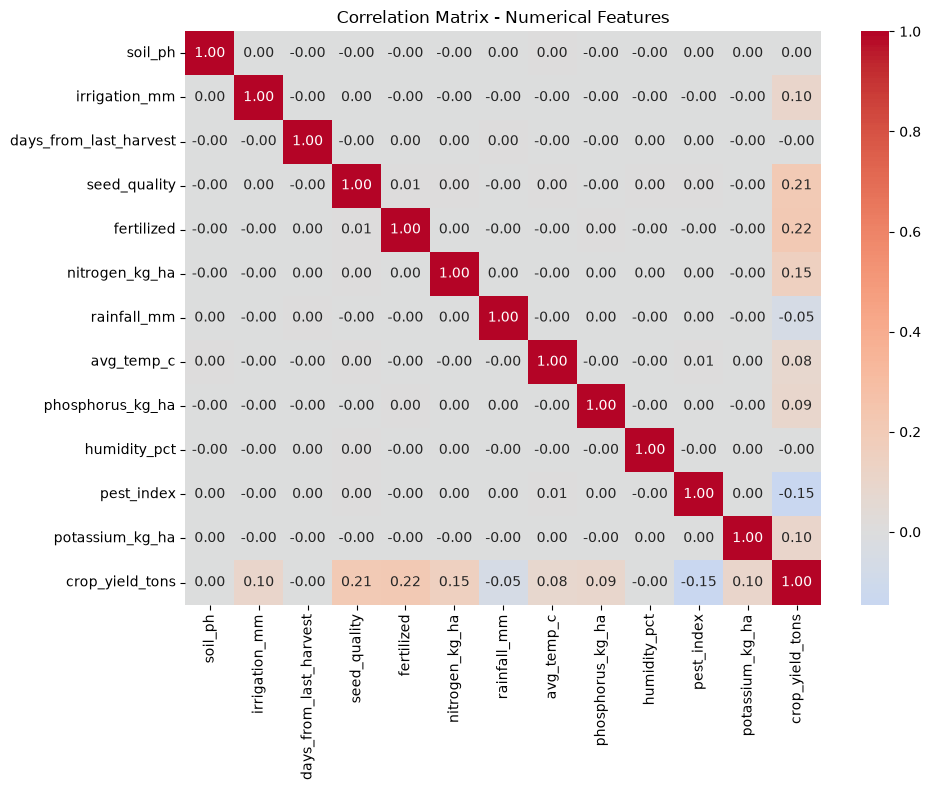

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix for numerical features
numeric_cols = ['soil_ph', 'irrigation_mm', 'days_from_last_harvest', 'seed_quality',
                 'fertilized', 'nitrogen_kg_ha', 'rainfall_mm', 'avg_temp_c',
                 'phosphorus_kg_ha', 'humidity_pct', 'pest_index', 'potassium_kg_ha',
                 'crop_yield_tons']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reconstruct crop_type labels from the one-hot columns (needed only for stratifying the split)
crop_dummy_cols = ['crop_type_cotton', 'crop_type_rice', 'crop_type_soybean', 'crop_type_wheat']
crop_type_labels = df[crop_dummy_cols].idxmax(axis=1).str.replace('crop_type_', '', regex=False)
all_zero = (df[crop_dummy_cols].sum(axis=1) == 0)
crop_type_labels[all_zero] = 'corn'  # the dropped baseline category

# Separate features (X) and target (y)
X = df.drop(columns=['crop_yield_tons'])
y = df['crop_yield_tons']

# 80/20 split, stratified by crop type
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=crop_type_labels, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Feature scaling: standardize numerical columns
numeric_cols = ['soil_ph', 'irrigation_mm', 'days_from_last_harvest', 'nitrogen_kg_ha',
                'rainfall_mm', 'avg_temp_c', 'phosphorus_kg_ha', 'humidity_pct',
                'pest_index', 'potassium_kg_ha']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nScaling complete. Sample of scaled training data:")
X_train_scaled[numeric_cols].describe()

Train shape: (197838, 28)
Test shape: (49460, 28)

Scaling complete. Sample of scaled training data:


,soil_ph,irrigation_mm,days_from_last_harvest,nitrogen_kg_ha,rainfall_mm,avg_temp_c,phosphorus_kg_ha,humidity_pct,pest_index,potassium_kg_ha
count,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05,1.978380e+05
mean,1.078467e-15,-1.580277e-16,6.464769e-19,2.758301e-17,-1.956670e-16,-2.482830e-16,-2.696527e-16,-6.591191e-16,-1.903515e-17,-5.028153e-19
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-4.703875e+00,-1.939260e+00,-9.971155e-01,-1.999113e+00,-3.901402e+00,-4.136283e+00,-2.232529e+00,-4.281788e+00,-1.755476e+00,-2.284137e+00
25%,-6.253976e-01,-7.275043e-01,-7.128403e-01,-7.075043e-01,-6.756072e-01,-6.317615e-01,-6.543031e-01,-6.428772e-01,-7.568102e-01,-6.654626e-01
50%,-4.759804e-03,-1.653496e-01,-3.031495e-01,-1.882486e-01,1.296113e-03,-4.767454e-02,-1.614553e-01,1.332041e-01,-1.326439e-01,-1.593827e-01
75%,6.306551e-01,5.592054e-01,3.908164e-01,4.963411e-01,6.735312e-01,7.311080e-01,4.496204e-01,7.731694e-01,6.163556e-01,4.658897e-01
max,4.576139e+00,7.454970e+00,9.596316e+00,1.017339e+01,4.907678e+00,4.430325e+00,1.038586e+01,1.821483e+00,4.111687e+00,9.396734e+00


In [10]:
# Reload the raw data into a new variable (df stays untouched)
df_clean = pd.read_csv('crop_yield_data.csv')

# Step 1: drop rows with missing values in the columns that only had a few missing
cols_minor_missing = ['irrigation_mm', 'days_from_last_harvest', 'nitrogen_kg_ha',
                      'rainfall_mm', 'avg_temp_c', 'humidity_pct', 'pest_index', 'crop_yield_tons']
df_clean = df_clean.dropna(subset=cols_minor_missing)

# Step 2: median imputation for the three columns with substantial missing values
for col in ['soil_ph', 'phosphorus_kg_ha', 'potassium_kg_ha']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Step 3: remove rows with impossible negative rainfall
df_clean = df_clean[df_clean['rainfall_mm'] >= 0]

print("Shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
df_clean.head()

Shape: (247298, 18)
Missing values: 0


,weather_zone,irrigation_method,soil_ph,irrigation_mm,days_from_last_harvest,seed_quality,soil_type,fertilized,nitrogen_kg_ha,season,rainfall_mm,avg_temp_c,crop_type,phosphorus_kg_ha,humidity_pct,pest_index,potassium_kg_ha,crop_yield_tons
0,humid,flood,6.51,116.0,100.0,low,sandy,no,127.15,winter,810.0,32.0,soybean,56.57,64.87,50.0,57.63,17.110
1,tropical,drip,6.51,259.0,9.0,medium,loam,no,116.43,summer,1162.0,27.0,soybean,45.17,83.36,30.0,43.17,21.135
2,tropical,flood,7.05,276.0,2.0,medium,peat,no,95.13,summer,1123.0,23.0,soybean,56.80,88.92,23.0,44.17,21.876
3,temperate,drip,5.81,136.0,45.0,medium,clay,yes,62.14,summer,841.0,27.0,corn,59.34,92.82,31.0,139.97,30.239
4,humid,drip,6.51,89.0,96.0,medium,sandy,yes,93.45,summer,1052.0,32.0,corn,54.58,85.83,19.0,67.20,24.966


In [3]:
df_check = pd.read_csv('crop_yield_cleaned.csv', sep=';')
print("Shape:", df_check.shape)
print("\nColumns:")
print(df_check.columns.tolist())

Shape: (247298, 15)

Columns:
['irrigation_method', 'soil_ph', 'irrigation_mm', 'seed_quality', 'soil_type', 'fertilized', 'nitrogen_kg_ha', 'rainfall_mm', 'avg_temp_c', 'crop_type', 'phosphorus_kg_ha', 'humidity_pct', 'pest_index', 'potassium_kg_ha', 'crop_yield_tons']


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the cleaned data (semicolon-separated)
df_clean = pd.read_csv('crop_yield_cleaned.csv', sep=';')
print("Shape:", df_clean.shape)

# Keep crop labels for stratifying the split (before encoding removes the column)
crop_labels = df_clean['crop_type']

# Encoding
df = df_clean.copy()
df['fertilized'] = df['fertilized'].map({'no': 0, 'yes': 1})
df['seed_quality'] = df['seed_quality'].map({'low': 0, 'medium': 1, 'high': 2})
nominal_cols = ['irrigation_method', 'soil_type', 'crop_type']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

print("Shape after encoding:", df.shape)

# Features and target
X = df.drop(columns=['crop_yield_tons'])
y = df['crop_yield_tons']

# 80/20 split, stratified by crop type
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=crop_labels, random_state=42
)

# Scale the continuous columns (fit on train only)
numeric_cols = ['soil_ph', 'irrigation_mm', 'nitrogen_kg_ha', 'rainfall_mm',
                 'avg_temp_c', 'phosphorus_kg_ha', 'humidity_pct',
                 'pest_index', 'potassium_kg_ha']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Shape: (247298, 15)
Shape after encoding: (247298, 22)
Train shape: (197838, 21)
Test shape: (49460, 21)


In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_validate

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

scoring = {
    'R2': 'r2',
    'RMSE': 'neg_root_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

results = {}

for name, model in models.items():
    print(f"Running 5-fold cross-validation for {name}...")
    cv_results = cross_validate(model, X_train_scaled, y_train, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {
        'R2': cv_results['test_R2'].mean(),
        'RMSE': -cv_results['test_RMSE'].mean(),
        'MAE': -cv_results['test_MAE'].mean()
    }
    print(f"  R²: {results[name]['R2']:.4f} | RMSE: {results[name]['RMSE']:.4f} | MAE: {results[name]['MAE']:.4f}\n")

print("All models evaluated.")

Running 5-fold cross-validation for Linear Regression...
  R²: 0.4367 | RMSE: 3.3122 | MAE: 2.6601

Running 5-fold cross-validation for Decision Tree...
  R²: 0.5593 | RMSE: 2.9298 | MAE: 2.3168

Running 5-fold cross-validation for Random Forest...
  R²: 0.7986 | RMSE: 1.9805 | MAE: 1.5684

Running 5-fold cross-validation for Gradient Boosting...
  R²: 0.7130 | RMSE: 2.3640 | MAE: 1.8755

All models evaluated.


In [3]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestRegressor(random_state=42, n_jobs=2)

search = RandomizedSearchCV(
    rf, param_distributions=param_grid, n_iter=10, cv=3,
    scoring='r2', random_state=42, n_jobs=2, verbose=2
)

search.fit(X_train_scaled, y_train)

print("Best parameters:", search.best_params_)
print("Best R² (cross-validated):", search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Best R² (cross-validated): 0.7978460376849549


In [4]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(random_state=42, n_jobs=-1)
final_model.fit(X_train_scaled, y_train)
print("Final model trained.")

Final model trained.


In [5]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = final_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Final test set results:")
print(f"R²:   {r2:.4f}")
print(f"RMSE: {rmse:.4f} tons")
print(f"MAE:  {mae:.4f} tons")


Final test set results:
R²:   0.8036
RMSE: 1.9628 tons
MAE:  1.5557 tons


In [6]:
import pandas as pd

importances = pd.Series(final_model.feature_importances_, index=X_train_scaled.columns)
importances = importances.sort_values(ascending=False)

print("Top 10 features:")
print(importances.head(10).round(4))

Top 10 features:
rainfall_mm         0.1976
avg_temp_c          0.1927
crop_type_rice      0.1007
crop_type_cotton    0.0997
fertilized          0.0490
nitrogen_kg_ha      0.0467
seed_quality        0.0412
pest_index          0.0392
irrigation_mm       0.0319
crop_type_wheat     0.0306
dtype: float64


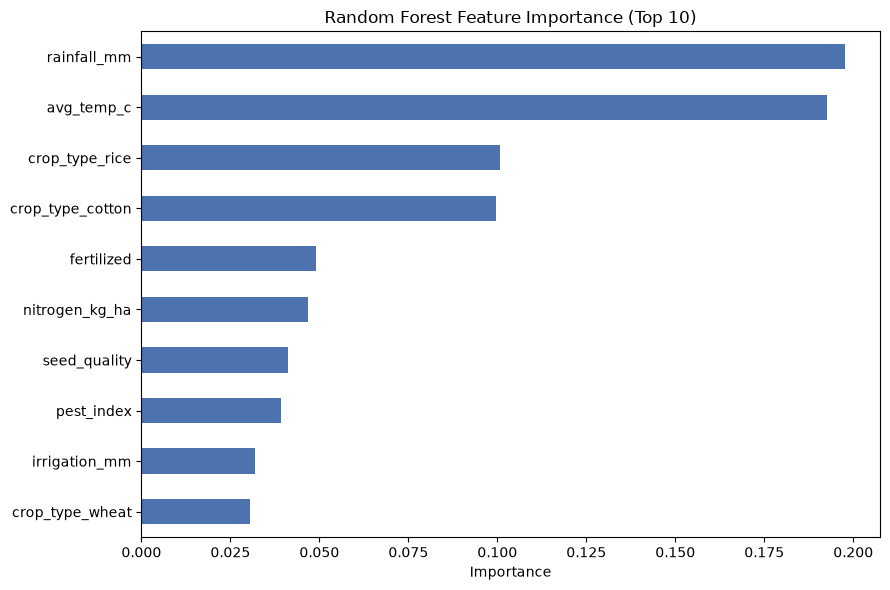

In [7]:
import matplotlib.pyplot as plt

top10 = importances.head(10)

plt.figure(figsize=(9, 6))
top10.sort_values().plot(kind='barh', color='#4C72B0')
plt.title('Random Forest Feature Importance (Top 10)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

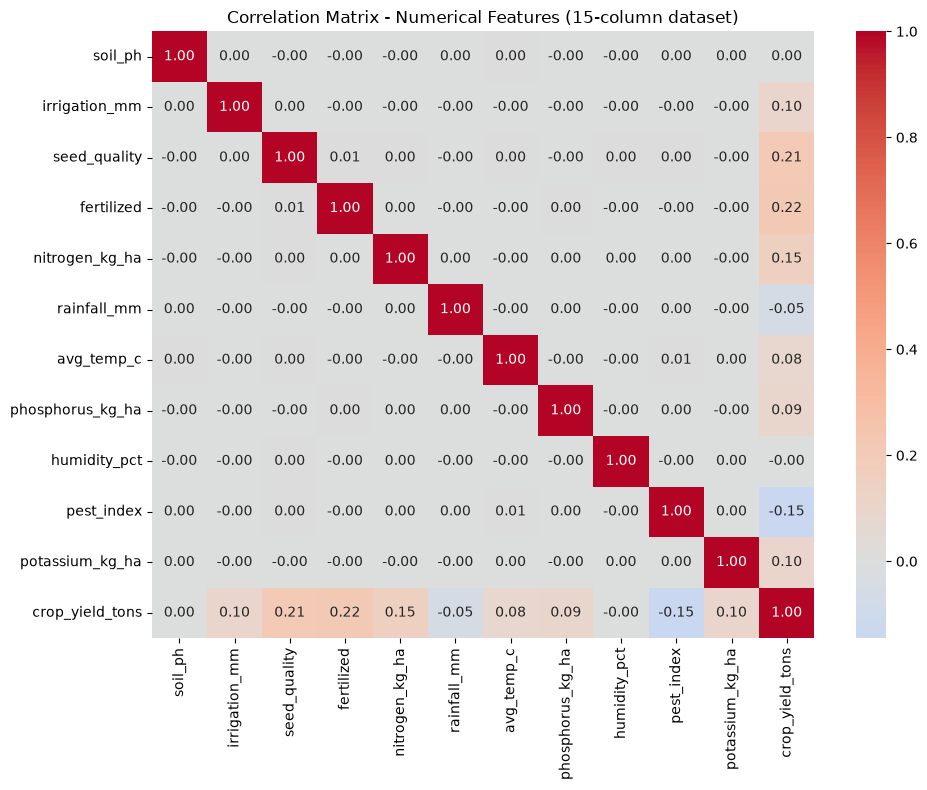

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make a temporary numeric-only copy for correlation purposes
df_corr = df_clean.copy()
df_corr['fertilized'] = df_corr['fertilized'].map({'no': 0, 'yes': 1})
df_corr['seed_quality'] = df_corr['seed_quality'].map({'low': 0, 'medium': 1, 'high': 2})

numeric_cols = ['soil_ph', 'irrigation_mm', 'seed_quality', 'fertilized',
                 'nitrogen_kg_ha', 'rainfall_mm', 'avg_temp_c',
                 'phosphorus_kg_ha', 'humidity_pct', 'pest_index',
                 'potassium_kg_ha', 'crop_yield_tons']

corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Numerical Features (15-column dataset)')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()